# Experiment 1: Simple Linear Regression

**Course:** AML ZC416 – Machine Learning Fundamentals
**Session Reference:** Contact Session 3 — Supervised Learning: Regression
**Duration:** 2 hours

---

## Aim
To implement Simple Linear Regression by deriving parameters using the closed-form Ordinary Least Squares method, training via Gradient Descent, and validating the results using scikit-learn — then evaluate the fitted model using standard regression metrics.

## Learning Outcomes
By the end of this experiment, you will be able to:
1. Explain the hypothesis function and cost function for simple linear regression.
2. Derive and manually compute regression coefficients using the least-squares method.
3. Implement linear regression using **scikit-learn**.
4. Implement **gradient descent** from scratch and compare it against the closed-form solution.
5. Evaluate a regression model using MAE, MSE, RMSE, and R².
6. Interpret the slope and intercept of a fitted line in the context of real data.


## Part 0 — Setup and Dataset

Run the cells below first. They import the required libraries and load (or generate) the dataset.
If running on **Google Colab**, all libraries are pre-installed — you only need to run the check.


In [3]:
import sys
print("Python version:", sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import __version__ as sklearn_version

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", sklearn_version)


Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
NumPy version: 2.5.2
Pandas version: 3.0.5
scikit-learn version: 1.9.0


**Checkpoint:** You should see four version numbers printed with no errors. If any library is missing, run:

```
!pip install numpy pandas matplotlib scikit-learn
```

in a new cell, then restart the runtime and re-run the check above.


### Load the Dataset

We use a simple two-column dataset (`YearsExperience`, `Salary`). If the CSV isn't available, a similar synthetic dataset is generated automatically so the notebook still runs end to end.


In [4]:
try:
    df = pd.read_csv('Salary_Data.csv')
except FileNotFoundError:
    rng = np.random.default_rng(42)
    years = np.sort(rng.uniform(1, 10, 30))
    salary = 25000 + 9000 * years + rng.normal(0, 4000, 30)
    df = pd.DataFrame({'YearsExperience': years, 'Salary': salary})

df.head()


,YearsExperience,Salary
0,1.394234,46114.695432
1,1.574355,37543.537679
2,1.847596,39579.394263
3,2.153023,41122.113334
4,2.388605,48961.366548


In [5]:
df.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,6.032249,79745.265366
std,2.663115,23958.102726
min,1.394234,37543.537679
25%,4.227346,59701.161908
50%,6.739883,86329.694339
75%,8.057297,98897.666035
max,9.780601,116898.523901


### Visualize the Data


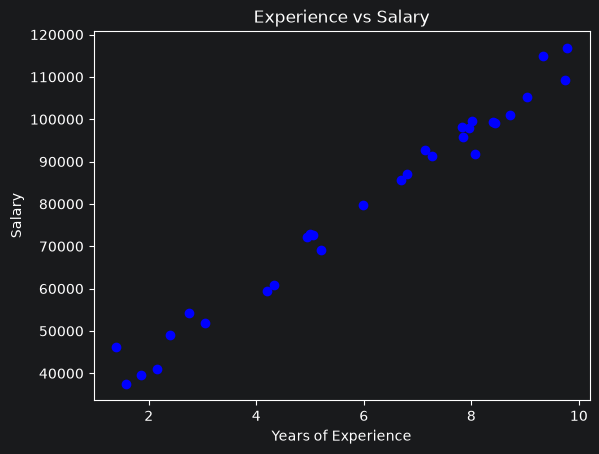

In [6]:
plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()


### Train-Test Split


In [7]:
from sklearn.model_selection import train_test_split

X = df[['YearsExperience']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", len(X_train), "| Test size:", len(X_test))


Train size: 24 | Test size: 6


---
## Part 1 — The Linear Regression Model

The hypothesis for simple linear regression is:

$$\hat{y} = \theta_0 + \theta_1 x$$

The parameters are chosen to minimize the **Mean Squared Error** cost function:

$$J(\theta_0, \theta_1) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

| Rank in course | Method | Idea |
|---|---|---|
| 1 | Closed-form (OLS) | Solve for $\theta_0, \theta_1$ directly using a formula |
| 2 | scikit-learn | Same closed-form solution, via a library call |
| 3 | Gradient Descent | Iteratively update $\theta_0, \theta_1$ to reduce $J$ |

We implement all three below and confirm they agree.


---
## Part 2 — Manual Computation (Closed-Form / Ordinary Least Squares)

### 2.1 Compute $\theta_0$ and $\theta_1$ using the least-squares formulas

$$\theta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2} \qquad \theta_0 = \bar{y} - \theta_1 \bar{x}$$


In [8]:
X_train_flat = X_train.flatten()
x_mean, y_mean = X_train_flat.mean(), y_train.mean()

theta1_manual = np.sum((X_train_flat - x_mean) * (y_train - y_mean)) / np.sum((X_train_flat - x_mean) ** 2)
theta0_manual = y_mean - theta1_manual * x_mean

print("Manual (OLS) -> theta0:", theta0_manual, " theta1:", theta1_manual)


Manual (OLS) -> theta0: 26518.344285049985  theta1: 8795.771577951664


### 2.2 Predict and Evaluate the Manual Model


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_manual = theta0_manual + theta1_manual * X_test.flatten()

mae_manual = mean_absolute_error(y_test, y_pred_manual)
mse_manual = mean_squared_error(y_test, y_pred_manual)
rmse_manual = np.sqrt(mse_manual)
r2_manual = r2_score(y_test, y_pred_manual)

print(f"Manual -> MAE: {mae_manual:.2f}  MSE: {mse_manual:.2f}  RMSE: {rmse_manual:.2f}  R2: {r2_manual:.4f}")


Manual -> MAE: 2513.54  MSE: 10477880.26  RMSE: 3236.96  R2: 0.9663


---
## Part 3 — scikit-learn Implementation


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("scikit-learn -> theta0:", model.intercept_, " theta1:", model.coef_[0])


scikit-learn -> theta0: 26518.344285049978  theta1: 8795.771577951666


### 3.1 Predict and Visualize the Fitted Line


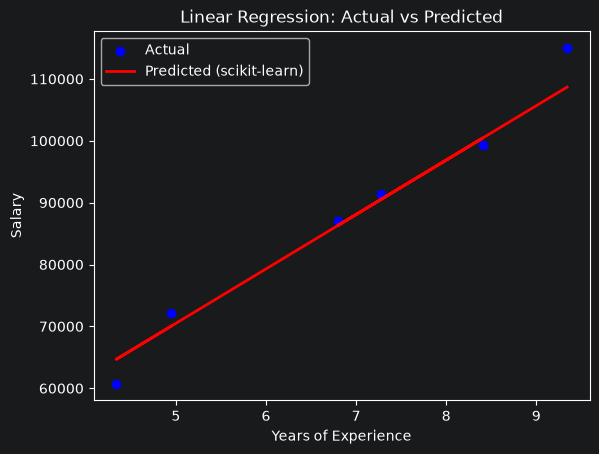

In [11]:
y_pred_sklearn = model.predict(X_test)

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_sklearn, color='red', linewidth=2, label='Predicted (scikit-learn)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()


### 3.2 Evaluate the scikit-learn Model


In [12]:
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred_sklearn)

print(f"scikit-learn -> MAE: {mae_sk:.2f}  MSE: {mse_sk:.2f}  RMSE: {rmse_sk:.2f}  R2: {r2_sk:.4f}")


scikit-learn -> MAE: 2513.54  MSE: 10477880.26  RMSE: 3236.96  R2: 0.9663


---
## Part 4 — Gradient Descent From Scratch


In [13]:
def gradient_descent(x, y, lr=0.1, epochs=1000):
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    for _ in range(epochs):
        y_pred = theta0 + theta1 * x
        error = y_pred - y
        d_theta0 = (1 / m) * np.sum(error)
        d_theta1 = (1 / m) * np.sum(error * x)
        theta0 -= lr * d_theta0
        theta1 -= lr * d_theta1
    return theta0, theta1

# Standardize X for stable, fast convergence
x_mean2, x_std2 = X_train_flat.mean(), X_train_flat.std()
X_train_norm = (X_train_flat - x_mean2) / x_std2

theta0_norm, theta1_norm = gradient_descent(X_train_norm, y_train, lr=0.1, epochs=1000)

# Convert normalized-space coefficients back to the original scale
theta1_gd = theta1_norm / x_std2
theta0_gd = theta0_norm - theta1_gd * x_mean2

print("Gradient Descent -> theta0:", theta0_gd, " theta1:", theta1_gd)


Gradient Descent -> theta0: 26518.344285049956  theta1: 8795.771577951657


> **Note:** Try changing `lr` (learning rate) or `epochs` above and re-run — a learning rate that is too high on **unnormalized** data will diverge, which is exactly why we standardize $x$ first.


### 4.1 Evaluate the Gradient Descent Model


In [14]:
y_pred_gd = theta0_gd + theta1_gd * X_test.flatten()

mae_gd = mean_absolute_error(y_test, y_pred_gd)
mse_gd = mean_squared_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent -> MAE: {mae_gd:.2f}  MSE: {mse_gd:.2f}  RMSE: {rmse_gd:.2f}  R2: {r2_gd:.4f}")


Gradient Descent -> MAE: 2513.54  MSE: 10477880.26  RMSE: 3236.96  R2: 0.9663


---
## Part 5 — Side-by-Side Comparison


In [15]:
comparison = pd.DataFrame({
    'Method': ['Manual (OLS)', 'scikit-learn', 'Gradient Descent'],
    'theta0 (Intercept)': [theta0_manual, model.intercept_, theta0_gd],
    'theta1 (Slope)': [theta1_manual, model.coef_[0], theta1_gd],
    'MAE': [mae_manual, mae_sk, mae_gd],
    'RMSE': [rmse_manual, rmse_sk, rmse_gd],
    'R2 Score': [r2_manual, r2_sk, r2_gd],
})
comparison


,Method,theta0 (Intercept),theta1 (Slope),MAE,RMSE,R2 Score
0,Manual (OLS),26518.344285,8795.771578,2513.535326,3236.955399,0.966322
1,scikit-learn,26518.344285,8795.771578,2513.535326,3236.955399,0.966322
2,Gradient Descent,26518.344285,8795.771578,2513.535326,3236.955399,0.966322


### Key takeaway
All three methods should converge to (approximately) the same $\theta_0, \theta_1$ and the same evaluation metrics, because they are solving the *same* optimization problem in different ways. The closed-form solution is exact and fast for one feature; gradient descent is slower here but is the approach that scales to the many-featured, non-linear models used later in this course.


---
## Part 6 — In-Lab Exercise (to be completed and shown to the instructor)

Complete the following in the empty cells below:

1. Repeat the experiment using a **different single-feature dataset** (e.g., study hours vs. exam marks, or advertising spend vs. sales).
2. Manually compute $\theta_0$ and $\theta_1$ for the **first 5 rows** of your dataset and verify against your code's output.
3. Introduce an artificial **outlier** into the dataset and re-fit the model. Report how much the slope and intercept change.
4. Try **three different learning rates** (e.g., 0.001, 0.1, 1.0) in your gradient descent implementation and plot the cost $J(\theta)$ over epochs for each. Which one diverges?


In [16]:
# TODO 1: Load a different single-feature dataset and repeat Parts 0-3
# your code here


In [17]:
# TODO 2: Manually compute theta0, theta1 for the first 5 rows
# your code here


In [18]:
# TODO 3: Add an outlier and re-fit; compare theta0, theta1 to the original fit
# your code here


In [19]:
# TODO 4: Try 3 learning rates in gradient descent and plot cost vs. epoch for each
# your code here
